# AE Checkpoint Evaluation

For each `.ckpt` in `checkpoints/`, computes the relative L2 error on the **physical** field U and displays a histogram.

In [2]:
import sys, os
os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')

# Always run from repo root (InferencePipelineAE uses paths relative to repo root)
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

sys.path.insert(0, 'src')

import glob
import re
import gc
import numpy as np
import torch
import torch.nn.functional as F_nn
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from laplace_surrogate.inference.pipeline_ae import InferencePipelineAE


## 1. Dataset loading and normalisation

In [3]:
DATA_PATH  = 'dataset/ch4_rotated.npy'
SPLIT_PATH = 'dataset/split.npz'
CKPT_DIR   = 'checkpoints'
CACHE_DIR  = 'notebooks/cache'
N          = 128
DT         = 1.0

os.makedirs(CACHE_DIR, exist_ok=True)

U_raw = np.load(DATA_PATH, mmap_mode='r')          # (ns, Nt, H, W)
ns, Nt_full, H, W = U_raw.shape
print(f'Dataset: {ns} sims, Nt={Nt_full}, {H}×{W}')

split     = np.load(SPLIT_PATH)
test_idx  = split['test_idx'].tolist()
train_idx = [i for i in range(ns) if i not in set(test_idx)]
print(f'Train: {len(train_idx)}  Test: {len(test_idx)}')


Dataset: 8100 sims, Nt=150, 128×128
Train: 6480  Test: 1620


In [4]:
def load_u(idx: int) -> np.ndarray:
    """Load and resize to (Nt, N, N) float32."""
    u = U_raw[idx].astype(np.float32)
    if u.shape[-1] != N:
        u_t = torch.from_numpy(u).unsqueeze(1)
        u_t = F_nn.interpolate(u_t, size=(N, N), mode='bilinear', align_corners=False)
        u   = u_t.squeeze(1).numpy()
    return u

## 2. Evaluation functions

In [5]:
def eval_ae(ckpt_path: str, idx_list: list, device='cpu', batch_size: int = 8) -> np.ndarray:
    """
    Reconstruit U via InferencePipelineAE et calcule le L2rel (%) sur le champ physique.
    Supporte LLAE et SLAE.
    """
    pipe = InferencePipelineAE.from_checkpoint(ckpt_path, device=device)
    name = os.path.basename(ckpt_path)

    l2rel_list = []
    for start in tqdm(range(0, len(idx_list), batch_size), desc=name, leave=False):
        batch_idx = idx_list[start:start + batch_size]
        U_batch   = np.stack([load_u(i) for i in batch_idx])   # (B, Nt, N, N)
        U_rec     = pipe.reconstruct(U_batch)                   # (B, Nt, N, N)

        for j in range(len(batch_idx)):
            denom = np.linalg.norm(U_batch[j])
            if denom >= 1e-12:
                l2rel_list.append(np.linalg.norm(U_rec[j] - U_batch[j]) / denom * 100.0)

        if device == 'cuda':
            torch.cuda.empty_cache()

    pipe.model.cpu()
    del pipe
    if device == 'cuda':
        torch.cuda.empty_cache()
    gc.collect()
    return np.array(l2rel_list)

## 3. Evaluation of all checkpoints

In [6]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

ckpt_paths = sorted([
    p for p in glob.glob(os.path.join(CKPT_DIR, '*.ckpt'))
    if (os.path.basename(p).startswith('llae_') or os.path.basename(p).startswith('slae_'))
])
print(f'{len(ckpt_paths)} AE checkpoints found:')
for p in ckpt_paths:
    print(' ', os.path.basename(p))

Device: cuda
9 AE checkpoints found:
  llae_ld64_K16_g0.0_ll-v1.ckpt
  llae_ld64_K16_g0.0_ll.ckpt
  llae_ld64_K32_g0.0_ll-v1.ckpt
  llae_ld64_K32_g0.0_ll.ckpt
  llae_ld64_K8_g0.0_ll-v1.ckpt
  llae_ld64_K8_g0.0_ll.ckpt
  slae_ld64_K16_g0.0_ol.ckpt
  slae_ld64_K32_g0.0_ol.ckpt
  slae_ld64_K8_g0.0_ol.ckpt


In [ ]:
def _cache_path(name: str) -> str:
    return os.path.join(CACHE_DIR, f'{name}.npz')

def _cache_valid(cache_file: str, ckpt_path: str) -> bool:
    if not os.path.exists(cache_file):
        return False
    data = np.load(cache_file, allow_pickle=True)
    return float(data['ckpt_mtime']) == os.path.getmtime(ckpt_path)

def _save_cache(name: str, ckpt_path: str, l2rel: np.ndarray):
    np.savez(
        _cache_path(name),
        l2rel      = l2rel,
        ckpt_mtime = np.float64(os.path.getmtime(ckpt_path)),
    )

def _load_cache(name: str) -> np.ndarray:
    return np.load(_cache_path(name))['l2rel']


device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}\n')

results = {}   # name → np.array L2rel (%)

for ckpt_path in ckpt_paths:
    name       = os.path.splitext(os.path.basename(ckpt_path))[0]
    model_type = 'llae' if name.startswith('llae') else 'slae'
    cache_file = _cache_path(name)

    if _cache_valid(cache_file, ckpt_path):
        l2 = _load_cache(name)
        print(f'[cache]   {name}')
    else:
        print(f'[compute] {name}  [{model_type}]')
        try:
            l2 = eval_ae(ckpt_path, test_idx, device=device)
            _save_cache(name, ckpt_path, l2)
        except Exception as e:
            print(f'   ERROR: {e}')
            continue

    results[name] = l2
    print(f'   median={np.median(l2):.2f}%  mean={np.mean(l2):.2f}%  p90={np.percentile(l2,90):.2f}%  n={len(l2)}')

print('\nDone.')

Device: cuda

[compute] llae_ld64_K16_g0.0_ll-v1  [llae]
Calcul des stats de normalisation sur le train set…


fit U_mean/std:   0%|          | 16/5184 [00:00<00:33, 153.73it/s]

llae_ld64_K16_g0.0_ll-v1.ckpt:   0%|          | 0/125 [00:00<?, ?it/s]

   median=106.29%  mean=107.87%  p90=124.93%  n=1000
[compute] llae_ld64_K16_g0.0_ll  [llae]
Calcul des stats de normalisation sur le train set…


KeyboardInterrupt: 

In [40]:
import re
from collections import defaultdict
from matplotlib.lines import Line2D

_CKPT_PAT = re.compile(r'^(slae|llae)_ld(\d+)_K(\d+)_g([0-9.]+)')

def _pretty_name(name: str) -> str:
    m = _CKPT_PAT.match(name)
    if not m:
        return name
    model = m.group(1).upper()
    ld    = m.group(2)
    K     = m.group(3)
    g     = float(m.group(4))
    g_str = str(int(g)) if g == int(g) else str(g).rstrip('0')
    return f'{model}  d={ld}, K={K}, γ={g_str}'

colors = {'slae': 'steelblue', 'llae': 'tomato'}

pat = re.compile(r'^(?P<ae>llae|slae)_ld(?P<ld>\d+)_K(?P<K>\d+)_g(?P<g>[0-9.]+)(?P<suffix>.*)$')

def _fmt_label(v):
    if isinstance(v, float) and v == int(v):
        return str(int(v))
    return str(v)

# Build rows for ablation plots
ae_rows = []
for name in results:
    m = pat.match(name)
    if not m:
        continue
    ae_rows.append({
        'name'  : name,
        'ae'    : m.group('ae'),
        'ld'    : int(m.group('ld')),
        'K'     : int(m.group('K')),
        'gamma' : float(m.group('g')),
        'suffix': m.group('suffix') or '',
    })

def _select_rows(ae_type, var_name, fixed):
    rows = [r for r in ae_rows
            if r['ae'] == ae_type and all(r[k] == v for k, v in fixed.items())]
    return sorted(rows, key=lambda r: r[var_name])

def _plot_family(ax, rows, var_name, xlabel, title):
    if not rows:
        ax.set_title(f"{title}\n(no matching checkpoints)")
        ax.axis('off')
        return

    groups = defaultdict(list)
    for r in rows:
        groups[r[var_name]].extend(results[r['name']].tolist())

    xs_vals   = sorted(groups.keys())
    datasets  = [groups[v] for v in xs_vals]
    positions = list(range(len(xs_vals)))

    parts = ax.violinplot(datasets, positions=positions,
                          widths=0.65, showmedians=True, showmeans=True, showextrema=True)
    for pc in parts['bodies']:
        pc.set_alpha(0.55)
    parts['cmedians'].set_color('black');   parts['cmedians'].set_linewidth(2.2)
    parts['cmeans'].set_color('orange');    parts['cmeans'].set_linewidth(1.8)
    parts['cmeans'].set_linestyle('--')
    parts['cmaxes'].set_linewidth(0.8)
    parts['cmins'].set_linewidth(0.8)
    parts['cbars'].set_linewidth(0.8)

    ax.set_xticks(positions)
    ax.set_xticklabels([_fmt_label(v) for v in xs_vals], fontsize=9)
    ax.set_xlim(-0.7, len(xs_vals) - 0.3)
    ax.legend(handles=[
        Line2D([0], [0], color='black',  linewidth=2.2,              label='median'),
        Line2D([0], [0], color='orange', linewidth=1.8, linestyle='--', label='mean'),
    ], fontsize=8)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('L2rel (%)')
    ax.grid(alpha=0.3, axis='y')

## 4. Histograms per checkpoint

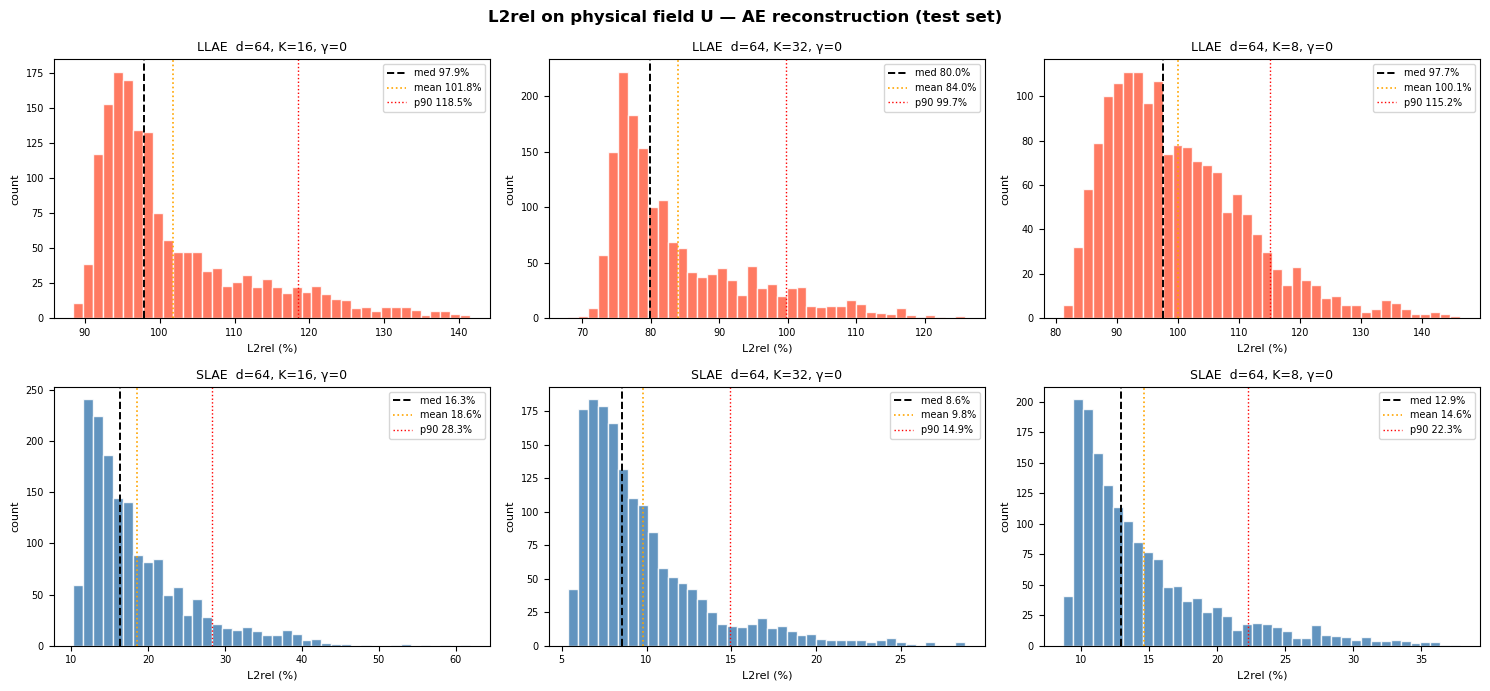

In [41]:
names  = list(results.keys())
n_ckpt = len(names)
ncols  = 3
nrows  = (n_ckpt + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
axes = axes.flatten()

colors = {'slae': 'steelblue', 'llae': 'tomato'}

for ax, name in zip(axes, names):
    l2      = results[name]
    mtype   = 'llae' if name.startswith('llae') else 'slae'
    median  = np.median(l2)
    mean    = np.mean(l2)
    p90     = np.percentile(l2, 90)

    ax.hist(l2, bins=40, color=colors[mtype], edgecolor='white', alpha=0.85)
    ax.axvline(median, color='black',  linestyle='--', linewidth=1.4, label=f'med {median:.1f}%')
    ax.axvline(mean,   color='orange', linestyle=':',  linewidth=1.2, label=f'mean {mean:.1f}%')
    ax.axvline(p90,    color='red',    linestyle=':',  linewidth=1.0, label=f'p90 {p90:.1f}%')
    ax.set_title(_pretty_name(name), fontsize=9)
    ax.set_xlabel('L2rel (%)', fontsize=8)
    ax.set_ylabel('count', fontsize=8)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

for ax in axes[n_ckpt:]:
    ax.set_visible(False)

fig.suptitle('L2rel on physical field U — AE reconstruction (test set)', fontsize=12, fontweight='bold')
fig.tight_layout()
plt.show()

## 5. Median comparison

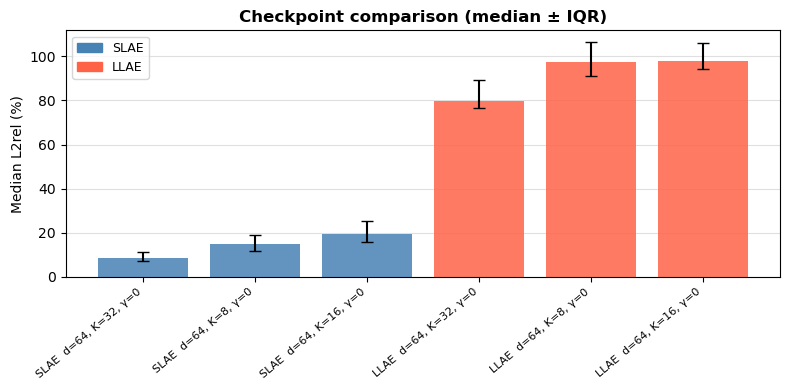

In [16]:
medians = {n: float(np.median(v)) for n, v in results.items()}
p25     = {n: float(np.percentile(v, 25)) for n, v in results.items()}
p75     = {n: float(np.percentile(v, 75)) for n, v in results.items()}

sorted_names = sorted(medians, key=lambda n: medians[n])
bar_colors   = [colors['llae' if n.startswith('llae') else 'slae'] for n in sorted_names]

fig, ax = plt.subplots(figsize=(max(8, n_ckpt * 0.9), 4))
x = np.arange(len(sorted_names))

bars = ax.bar(x, [medians[n] for n in sorted_names], color=bar_colors, alpha=0.85, zorder=2)

# IQR error bars
yerr_low  = [medians[n] - p25[n] for n in sorted_names]
yerr_high = [p75[n] - medians[n] for n in sorted_names]
ax.errorbar(x, [medians[n] for n in sorted_names],
            yerr=[yerr_low, yerr_high],
            fmt='none', color='black', capsize=4, linewidth=1.5, zorder=3)

ax.set_xticks(x)
ax.set_xticklabels([_pretty_name(n) for n in sorted_names], rotation=40, ha='right', fontsize=8)
ax.set_ylabel('Median L2rel (%)')
ax.set_title('Checkpoint comparison (median ± IQR)', fontweight='bold')
ax.grid(axis='y', alpha=0.4, zorder=0)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='steelblue', label='SLAE'),
    Patch(color='tomato',    label='LLAE'),
], fontsize=9)

fig.tight_layout()
plt.show()

## 6. Summary 

In [29]:
print(f"{'Checkpoint':<40}  {'type':^5}  {'median':>8}  {'mean':>8}  {'p90':>8}  {'n':>5}")
print('-' * 82)
for n in sorted(results, key=lambda n: np.median(results[n])):
    l2    = results[n]
    mtype = 'llae' if n.startswith('llae') else 'slae'
    print(f'{n:<40}  {mtype:^5}  {np.median(l2):>7.2f}%  {np.mean(l2):>7.2f}%  {np.percentile(l2,90):>7.2f}%  {len(l2):>5}')

Checkpoint                                type     median      mean       p90      n
----------------------------------------------------------------------------------
llae_ld128_K16_g0.01                      llae      2.92%     3.15%     4.38%   1620
llae_ld64_K32_g0.01                       llae      3.19%     3.53%     5.11%   1620
llae_ld64_K16_g0.01                       llae      3.20%     3.47%     5.04%   1620
llae_ld64_K16_g0.0                        llae      3.26%     3.61%     5.24%   1620
llae_ld64_K16_g0.001                      llae      3.32%     3.65%     5.16%   1620
llae_ld64_K8_g0.01                        llae      3.35%     3.66%     5.26%   1620
llae_ld32_K16_g0.01                       llae      3.43%     3.85%     5.60%   1620
slae_ld64_K16_g0.0                        slae      7.78%     8.11%     9.91%   1620
slae_ld64_K16_g0.001                      slae      7.82%     8.27%    10.36%   1620
slae_ld128_K16_g0.01                      slae      7.98%     8.40%

In [30]:
rows_gamma = _select_rows('llae', 'gamma', {'ld': 64, 'K': 16})
rows_K     = _select_rows('llae', 'K',     {'ld': 64, 'gamma': 0.01})
rows_ld    = _select_rows('llae', 'ld',    {'K': 16,  'gamma': 0.01})

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
_plot_family(axes[0], rows_gamma, 'gamma', 'γ',               'LLAE: effect of γ (ld=64, K=16)')
_plot_family(axes[1], rows_K,     'K',     'K',               'LLAE: effect of K (ld=64, γ=0.01)')
_plot_family(axes[2], rows_ld,    'ld',    'latent dim (ld)', 'LLAE: effect of latent dim (K=16, γ=0.01)')

fig.suptitle('LLAE — L2rel distributions (test set)', fontweight='bold')
fig.tight_layout()
plt.show()


In [32]:
rows_gamma_s = _select_rows('slae', 'gamma', {'ld': 64, 'K': 16})
rows_K_s     = _select_rows('slae', 'K',     {'ld': 64, 'gamma': 0.01})
rows_ld_s    = _select_rows('slae', 'ld',    {'K': 16,  'gamma': 0.01})

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
_plot_family(axes[0], rows_gamma_s, 'gamma', 'γ',               'SLAE: effect of γ (ld=64, K=16)')
_plot_family(axes[1], rows_K_s,     'K',     'K',               'SLAE: effect of K (ld=64, γ=0.01)')
_plot_family(axes[2], rows_ld_s,    'ld',    'latent dim (ld)', 'SLAE: effect of latent dim (K=16, γ=0.01)')

fig.suptitle('SLAE — L2rel distributions (test set)', fontweight='bold')
fig.tight_layout()
plt.show()
